In [2]:
import subprocess, os, re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Verifikasi NVCC
r = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print('=== NVCC Version ==='); print(r.stdout.strip())

# Info GPU
r2 = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n=== GPU Info ==='); print(r2.stdout)
def check_command(command):
    """Memeriksa apakah perintah dapat dijalankan di sistem."""
    try:
        r = subprocess.run(command, capture_output=True, text=True, shell=True)
        return r.returncode == 0, r.stdout.strip()
    except Exception:
        return False, ""

print("🔍 Memeriksa Kebutuhan Dasar CUDA Programming...\n")

# 1. Verifikasi NVIDIA Driver via nvidia-smi
has_smi, smi_out = check_command('nvidia-smi')
print('=== 1. GPU & Driver Info (nvidia-smi) ===')
if has_smi:
    print("\n".join(smi_out.split('\n')[:5])) 
else:
    print("❌ Driver NVIDIA tidak terdeteksi atau perintah 'nvidia-smi' tidak ditemukan.")

print('\n' + '='*40 + '\n')

# 2. Verifikasi CUDA Compiler (nvcc)
has_nvcc, nvcc_out = check_command('nvcc --version')
print('=== 2. NVCC Version ===')
if has_nvcc:
    print(nvcc_out)
else:
    print("❌ CUDA Compiler (nvcc) TIDAK ditemukan di PATH.")

print('\n' + '='*40 + '\n')

# 3. Kesimpulan Evaluasi
if has_smi and has_nvcc:
    print("✅ SEMUA AMAN! Environment Anda sudah siap untuk CUDA programming.")
    print("Lompat langsung ke Cell 4 (Setup Direktori).")
else:
    print("⚠️ Environment BELUM siap. Silakan instal cuda-nvcc di conda.")
# Buat direktori kerja
os.makedirs('cuda_files', exist_ok=True)
print('Direktori cuda_files siap.')

# Cek compute capability GPU
r3 = subprocess.run(
    'nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv,noheader',
    shell=True, capture_output=True, text=True)
print('GPU Details:', r3.stdout.strip())


=== NVCC Version ===
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2026 NVIDIA Corporation
Built on Fri_Apr_24_19:26:09_Pacific_Daylight_Time_2026
Cuda compilation tools, release 13.3, V13.3.33
Build cuda_13.3.r13.3/compiler.37862127_0

=== GPU Info ===
Sun Jun 14 16:43:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:0

In [ ]:
%%writefile cuda_files/vector_add_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N) {
    for (int i = 0; i < N; i++) C[i] = A[i] + B[i];
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i = 0; i < N; i++) {
        A[i] = (float)rand()/RAND_MAX;
        B[i] = (float)rand()/RAND_MAX;
    }
    auto t0 = std::chrono::high_resolution_clock::now();
    vector_add_cpu(A.data(), B.data(), C.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok = true;
    for (int i=0;i<10;i++) if (fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw = (3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,ms,bw,(int)ok);
    return 0;
}


In [4]:
!wsl g++ -O2 -std=c++11 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu
!wsl ./cuda_files/vec_cpu 10000000

N=10000000 TIME_MS=8.7959 BW=13.6428 CORRECT=1


In [ ]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}

In [5]:
!wsl g++ -O2 -std=c++11 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp
!wsl ./cuda_files/vec_omp 10000000 4

N=10000000 THREADS=4 TIME_MS=5.2628 BW=22.8015 CORRECT=1


In [30]:
import os

path = r'C:\Users\LOQ\cuda_files\vector_add_cuda.cu'

cuda_code = """#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>

#define CHECK(call) { cudaError_t e=call; if(e!=cudaSuccess){ fprintf(stderr,"CUDA error %s:%d: %s\\n",__FILE__,__LINE__,cudaGetErrorString(e)); exit(1);} }

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}

int main(int argc, char* argv[]) {
    int N = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);
    float *h_A=new float[N], *h_B=new float[N], *h_C=new float[N];
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));
    int blocks = (N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));
    float total = t_htod + t_kernel + t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\\n",N,TPB,blocks,t_htod,t_kernel,t_dtoh,total,(int)ok);
    delete[]h_A;delete[]h_B;delete[]h_C;
    CHECK(cudaFree(d_A));CHECK(cudaFree(d_B));CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0));CHECK(cudaEventDestroy(ev1));
    return 0;
}"""

with open(path, 'w', encoding='utf-8') as f:
    f.write(cuda_code)

print(f'Ukuran: {os.path.getsize(path)} bytes')

Ukuran: 2220 bytes


In [31]:
!wsl nvcc -O2 -std=c++11 /mnt/c/Users/LOQ/cuda_files/vector_add_cuda.cu -o /mnt/c/Users/LOQ/cuda_files/vec_cuda
!wsl /mnt/c/Users/LOQ/cuda_files/vec_cuda 10000000 256

N=10000000 TPB=256 BLOCKS=39063 HTOD=13.5702 KERNEL=375.4230 DTOH=26.4655 TOTAL=415.4587 CORRECT=1


In [ ]:
import os
path = r'C:\Users\LOQ\cuda_files\vector_add_pinned.cu'
cuda_code = """#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>
#define CHECK(call) { cudaError_t e=call; if(e!=cudaSuccess){ fprintf(stderr,"CUDA error %s:%d: %s\\n",__FILE__,__LINE__,cudaGetErrorString(e)); exit(1);} }
__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) C[idx] = A[idx] + B[idx];
}
int main(int argc, char* argv[]) {
    int N   = (argc>1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc>2) ? atoi(argv[2]) : 256;
    size_t sz = N * sizeof(float);
    float *h_A, *h_B, *h_C;
    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));
    srand(42);
    for(int i=0;i<N;i++){h_A[i]=(float)rand()/RAND_MAX;h_B[i]=(float)rand()/RAND_MAX;}
    float *d_A,*d_B,*d_C;
    CHECK(cudaMalloc(&d_A,sz)); CHECK(cudaMalloc(&d_B,sz)); CHECK(cudaMalloc(&d_C,sz));
    cudaEvent_t ev0,ev1; CHECK(cudaEventCreate(&ev0)); CHECK(cudaEventCreate(&ev1));
    float t_htod, t_kernel, t_dtoh;
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(d_A,h_A,sz,cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B,h_B,sz,cudaMemcpyHostToDevice));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod,ev0,ev1));
    int blocks=(N+TPB-1)/TPB;
    CHECK(cudaEventRecord(ev0));
    vec_add<<<blocks,TPB>>>(d_A,d_B,d_C,N);
    CHECK(cudaGetLastError());
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel,ev0,ev1));
    CHECK(cudaEventRecord(ev0));
    CHECK(cudaMemcpy(h_C,d_C,sz,cudaMemcpyDeviceToHost));
    CHECK(cudaEventRecord(ev1)); CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh,ev0,ev1));
    float total=t_htod+t_kernel+t_dtoh;
    bool ok=true; for(int i=0;i<10;i++) if(fabs(h_C[i]-(h_A[i]+h_B[i]))>1e-6){ok=false;break;}
    printf("N=%d TPB=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\\n",N,TPB,t_htod,t_kernel,t_dtoh,total,(int)ok);
    CHECK(cudaFreeHost(h_A)); CHECK(cudaFreeHost(h_B)); CHECK(cudaFreeHost(h_C));
    CHECK(cudaFree(d_A)); CHECK(cudaFree(d_B)); CHECK(cudaFree(d_C));
    CHECK(cudaEventDestroy(ev0)); CHECK(cudaEventDestroy(ev1));
    return 0;
}"""
with open(path, 'w', encoding='utf-8') as f:
    f.write(cuda_code)
print(f'Ukuran: {os.path.getsize(path)} bytes')

In [33]:
!wsl nvcc -O2 -std=c++11 /mnt/c/Users/LOQ/cuda_files/vector_add_pinned.cu -o /mnt/c/Users/LOQ/cuda_files/vec_pinned
!wsl /mnt/c/Users/LOQ/cuda_files/vec_pinned 10000000 256

N=10000000 TPB=256 HTOD=15.0757 KERNEL=3.2602 DTOH=6.3670 TOTAL=24.7028 CORRECT=1


In [38]:
import subprocess
import pandas as pd

BASE = "/mnt/c/Users/LOQ/cuda_files"

def parse_cpu(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

def parse_cuda(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
results = []

for N in sizes:
    row = {'N': N}

    # CPU Serial
    r = subprocess.run(f'wsl {BASE}/vec_cpu {N}', shell=True, capture_output=True, text=True)
    d = parse_cpu(r.stdout); row['cpu_ms'] = float(d.get('TIME_MS',0))

    # OpenMP (4 thread)
    r = subprocess.run(f'wsl {BASE}/vec_omp {N} 4', shell=True, capture_output=True, text=True)
    d = parse_cpu(r.stdout); row['omp_ms'] = float(d.get('TIME_MS',0))

    # CUDA Basic
    r = subprocess.run(f'wsl {BASE}/vec_cuda {N} 256', shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    row['cuda_htod']   = float(d.get('HTOD',0))
    row['cuda_kernel'] = float(d.get('KERNEL',0))
    row['cuda_dtoh']   = float(d.get('DTOH',0))
    row['cuda_total']  = float(d.get('TOTAL',0))

    # CUDA Pinned
    r = subprocess.run(f'wsl {BASE}/vec_pinned {N} 256', shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout); row['pinned_total'] = float(d.get('TOTAL',0))

    results.append(row)
    print(f'N={N:>12,}: cpu={row["cpu_ms"]:8.2f}ms  omp={row["omp_ms"]:7.2f}ms  cuda={row["cuda_total"]:7.2f}ms  pinned={row["pinned_total"]:7.2f}ms')

df = pd.DataFrame(results)
print('\n=== Eksperimen selesai ===')

N=       1,000: cpu=    0.00ms  omp=   0.57ms  cuda=   4.15ms  pinned=   3.21ms
N=      10,000: cpu=    0.01ms  omp=   0.40ms  cuda=   2.34ms  pinned=   3.51ms
N=     100,000: cpu=    0.06ms  omp=   0.36ms  cuda=   4.06ms  pinned=   2.15ms
N=   1,000,000: cpu=    0.82ms  omp=   1.33ms  cuda=  11.52ms  pinned=   5.90ms
N=  10,000,000: cpu=   10.26ms  omp=   6.05ms  cuda=  73.52ms  pinned=  17.61ms
N= 100,000,000: cpu=   79.70ms  omp=  83.83ms  cuda= 689.57ms  pinned= 201.23ms

=== Eksperimen selesai ===


In [39]:
# Hitung Speedup dan Bandwidth
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000  # GB/s
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

# Cetak tabel ringkasan
print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))

print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))

=== Tabel Waktu Eksekusi (ms) ===
        N  cpu_ms  omp_ms  cuda_total  pinned_total
     1000  0.0006  0.5703      4.1461        3.2089
    10000  0.0051  0.4013      2.3416        3.5143
   100000  0.0596  0.3634      4.0588        2.1494
  1000000  0.8223  1.3254     11.5176        5.9043
 10000000 10.2608  6.0457     73.5240       17.6091
100000000 79.6991 83.8325    689.5698      201.2302

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.001052      0.000145        0.000187
    10000     0.012709      0.002178        0.001451
   100000     0.164007      0.014684        0.027729
  1000000     0.620416      0.071395        0.139271
 10000000     1.697206      0.139557        0.582699
100000000     0.950695      0.115578        0.396059


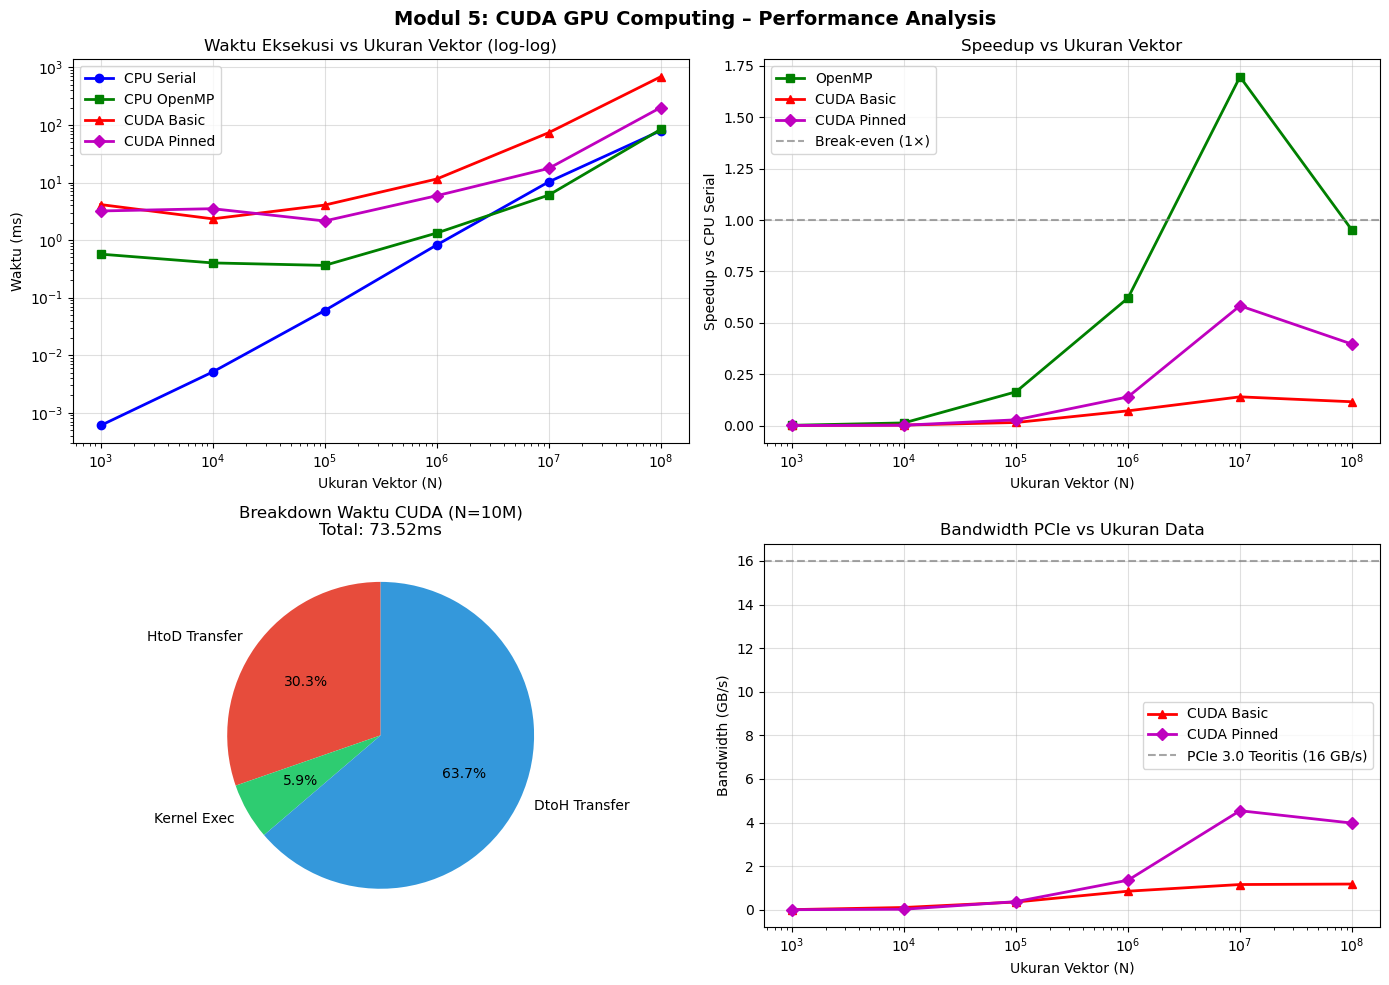

Grafik disimpan ke cuda_files/performance_analysis.png


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

# Grafik 1: Waktu Eksekusi (log scale)
ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],    'b-o', label='CPU Serial',  linewidth=2)
ax.loglog(df['N'], df['omp_ms'],    'g-s', label='CPU OpenMP',  linewidth=2)
ax.loglog(df['N'], df['cuda_total'],'r-^', label='CUDA Basic',  linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 2: Speedup vs CPU Serial
ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 3: CUDA Breakdown (10M elemen)
ax = axes[1,0]
row10m = df[df['N']==10_000_000].iloc[0]
labels_b = ['HtoD Transfer','Kernel Exec','DtoH Transfer']
vals_b = [row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']]
colors_b = ['#E74C3C','#2ECC71','#3498DB']
wedges,texts,autotexts = ax.pie(vals_b, labels=labels_b, colors=colors_b,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
ax.set_title(f'Breakdown Waktu CUDA (N=10M)\nTotal: {row10m["cuda_total"]:.2f}ms')

# Grafik 4: Bandwidth PCIe
ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\LOQ\cuda_files\performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke cuda_files/performance_analysis.png')

TPB=   32: kernel=4.5693ms  total=63.4497ms
TPB=   64: kernel=3.8530ms  total=65.9406ms
TPB=  128: kernel=3.0093ms  total=65.4540ms
TPB=  256: kernel=2.8556ms  total=50.5394ms
TPB=  512: kernel=2.0542ms  total=52.0578ms
TPB= 1024: kernel=3.3269ms  total=65.6165ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     4.5693   63.4497
              64  156250     3.8530   65.9406
             128   78125     3.0093   65.4540
             256   39063     2.8556   50.5394
             512   19532     2.0542   52.0578
            1024    9766     3.3269   65.6165


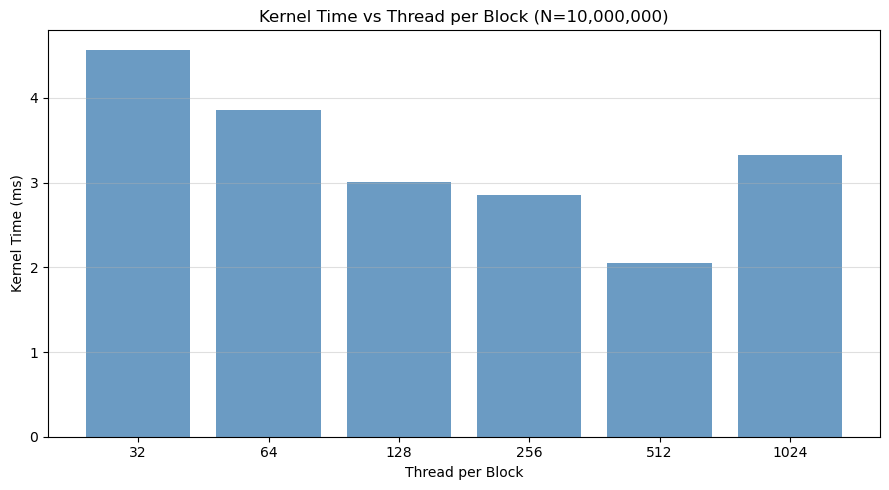

In [43]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

BASE = "/mnt/c/Users/LOQ/cuda_files"

def parse_cuda(out):
    d = {}
    for tok in out.split():
        if '=' in tok:
            k, v = tok.split('=')
            d[k] = v
    return d

tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'wsl {BASE}/vec_cuda {N_test} {tpb}',
                        shell=True, capture_output=True, text=True)

    # Debug: tampilkan jika ada masalah
    if r.returncode != 0 or not r.stdout.strip():
        print(f"!! TPB={tpb} GAGAL")
        print("   STDOUT:", repr(r.stdout))
        print("   STDERR:", repr(r.stderr))
        print("   Return code:", r.returncode)

    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL', 0)),
        'Total_ms'       : float(d.get('TOTAL', 0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(r'C:\Users\LOQ\cuda_files\tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
print('=== Breakdown CUDA Basic (ms) ===')
print(df[['N','cuda_htod','cuda_kernel','cuda_dtoh']].to_string(index=False))

=== Breakdown CUDA Basic (ms) ===
        N  cuda_htod  cuda_kernel  cuda_dtoh
     1000     1.2605       2.5856     0.3000
    10000     0.6985       1.5688     0.0743
   100000     1.6266       1.7973     0.6349
  1000000     3.5691       2.1114     5.8372
 10000000    22.2882       4.3731    46.8628
100000000   138.4036      10.8740   540.2921


In [46]:
import subprocess
BASE = "/mnt/c/Users/LOQ/cuda_files"

def parse_cuda(out):
    d = {}
    for tok in out.split():
        if '=' in tok:
            k, v = tok.split('=')
            d[k] = v
    return d

pinned_breakdown = []
for N in sizes:
    r = subprocess.run(f'wsl {BASE}/vec_pinned {N} 256', shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    pinned_breakdown.append({
        'N': N,
        'pinned_htod':   float(d.get('HTOD',0)),
        'pinned_kernel': float(d.get('KERNEL',0)),
        'pinned_dtoh':   float(d.get('DTOH',0)),
    })

df_pinned_bd = pd.DataFrame(pinned_breakdown)
print(df_pinned_bd.to_string(index=False))

        N  pinned_htod  pinned_kernel  pinned_dtoh
     1000       0.8349         2.0720       0.0404
    10000       0.9660         1.4152       0.0324
   100000       0.9365         1.4246       0.0644
  1000000       1.5722         1.4588       0.4401
 10000000       7.9184         2.4353       4.2340
100000000      75.8104        10.2596      45.7989


In [47]:
table_34 = df[['N','cuda_htod','cuda_kernel','cuda_dtoh']].merge(df_pinned_bd, on='N')
table_34.columns = ['Ukuran Vektor','HtoD (Basic)','Kernel (Basic)','DtoH (Basic)','HtoD (Pinned)','Kernel (Pinned)','DtoH (Pinned)']
print(table_34.to_string(index=False))

 Ukuran Vektor  HtoD (Basic)  Kernel (Basic)  DtoH (Basic)  HtoD (Pinned)  Kernel (Pinned)  DtoH (Pinned)
          1000        1.2605          2.5856        0.3000         0.8349           2.0720         0.0404
         10000        0.6985          1.5688        0.0743         0.9660           1.4152         0.0324
        100000        1.6266          1.7973        0.6349         0.9365           1.4246         0.0644
       1000000        3.5691          2.1114        5.8372         1.5722           1.4588         0.4401
      10000000       22.2882          4.3731       46.8628         7.9184           2.4353         4.2340
     100000000      138.4036         10.8740      540.2921        75.8104          10.2596        45.7989


In [48]:
row10m = df[df['N']==10_000_000].iloc[0]
htod, kernel, dtoh = row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']
total = htod + kernel + dtoh

print(f"HtoD Transfer : {htod:.4f} ms  ({htod/total*100:.2f}%)")
print(f"Kernel Exec   : {kernel:.4f} ms  ({kernel/total*100:.2f}%)")
print(f"DtoH Transfer : {dtoh:.4f} ms  ({dtoh/total*100:.2f}%)")
print(f"Total         : {total:.4f} ms  (100%)")

HtoD Transfer : 22.2882 ms  (30.31%)
Kernel Exec   : 4.3731 ms  (5.95%)
DtoH Transfer : 46.8628 ms  (63.74%)
Total         : 73.5241 ms  (100%)


In [49]:
import subprocess
BASE = "/mnt/c/Users/LOQ/cuda_files"
r = subprocess.run(f'wsl {BASE}/vec_cuda 10000000 256', shell=True, capture_output=True, text=True)
print("STDOUT:", repr(r.stdout))
print("STDERR:", repr(r.stderr))
print("Return code:", r.returncode)

STDOUT: 'N=10000000 TPB=256 BLOCKS=39063 HTOD=12.6564 KERNEL=2.6963 DTOH=26.8937 TOTAL=42.2464 CORRECT=1\n'
STDERR: ''
Return code: 0


In [51]:
row100m = df[df['N']==100_000_000].iloc[0]
PCIE_THEORETICAL = 16  # GB/s (PCIe 3.0 x16 / PCIe 4.0 x8)

bw_basic  = row100m['pcie_bw_cuda']
bw_pinned = row100m['pcie_bw_pinned']
efficiency = bw_pinned / PCIE_THEORETICAL * 100
improvement = (bw_pinned - bw_basic) / bw_basic * 100

print(f"BW CUDA Basic (N=100M)  : {bw_basic:.3f} GB/s")
print(f"BW CUDA Pinned (N=100M) : {bw_pinned:.3f} GB/s")
print(f"PCIe Teoritis           : {PCIE_THEORETICAL} GB/s")
print(f"PCIe Efficiency         : {efficiency:.2f}%")
print(f"Peningkatan dgn Pinned  : {improvement:.2f}%")

BW CUDA Basic (N=100M)  : 1.179 GB/s
BW CUDA Pinned (N=100M) : 3.976 GB/s
PCIe Teoritis           : 16 GB/s
PCIe Efficiency         : 24.85%
Peningkatan dgn Pinned  : 237.27%
